# Weekday and Weekend Differences in Shared Mobility Patterns

## A Bike-Share Case Study Using 2025 Chicago Divvy Data

This notebook is the proposal-facing summary layer. The reproducible data cleaning and analysis pipeline stays in `src/`, while this notebook reads the generated CSV tables and figures from `outputs/` and `figures/`.

In [1]:
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

OUTPUTS = ROOT / "outputs"
FIGURES = ROOT / "figures"

pd.options.display.float_format = "{:,.3f}".format

def read_output_csv(filename):
    path = OUTPUTS / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing output file: {path}. Run the src pipeline first.")
    return pd.read_csv(path)

def show_png(filename, figsize=(8, 5)):
    path = FIGURES / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing figure file: {path}. Run the src pipeline first.")
    image = mpimg.imread(path)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.axis("off")
    plt.show()

## Research Question

How do weekday and weekend Divvy trips in Chicago differ in trip duration, straight-line distance, and start-location concentration during 2025?

This question is intentionally measurable. It maps directly to three baseline indicators used throughout the notebook:

- Trip duration
- Straight-line trip length
- Start-location spatial density

The station-level dwell proxy is treated as a secondary availability signal, not as a primary movement metric.


## Proposal Objective and Rubric Fit

This project is a **comparative analysis**. It compares weekday and weekend shared-bike mobility patterns in Chicago during 2025 using the same cleaned Divvy trip dataset and the same reproducible pipeline.

The core objective is to test whether weekend trips differ from weekday trips in three observable movement signals: trip duration, straight-line trip length, and start-location density. A station-level dwell proxy is included as a secondary availability metric, but it should not be described as true bike-level dwell time.


## Hypotheses / Expected Patterns

The proposal will test three expected patterns:

1. Weekend trips will have longer median duration than weekday trips, because weekend rides are more likely to include recreational or flexible travel.
2. Weekday start locations will be more concentrated around commute-oriented areas, while weekend start locations may be more visible around parks, lakefront areas, and leisure districts.
3. Trip counts will be higher in warmer months, but weekday/weekend differences should still be examined after seasonal patterns are visible.


## Data and Reproducible Pipeline

The project uses monthly 2025 Chicago Divvy trip CSV files. The source data is cleaned and summarized with Python scripts in `src/`.

To reproduce this notebook, first run the pipeline scripts from the project root in this order, then run this notebook:

1. `01_combine_and_clean.py`
2. `02_eda_trip_patterns.py`
3. `03_dwell_proxy.py`
4. `04_spatial_heatmaps.py`
5. `05_optional_weather_merge.py`

This notebook does not replace those scripts. It presents the generated CSV tables and figures from `outputs/` and `figures/` so the proposal can stay concise and evidence-based.


In [2]:
cleaning_summary = read_output_csv("cleaning_summary.csv")
weekday_weekend_counts = read_output_csv("weekday_weekend_counts.csv")
monthly_counts = read_output_csv("monthly_counts_by_day_type.csv")
trip_summary = read_output_csv("trip_summary_by_day_type.csv")
dwell_summary = read_output_csv("dwell_proxy_summary_by_day_type.csv")

## Dataset Scope and Coordinate System

The dataset comes from the official Chicago Divvy monthly trip records. Each row represents one observed trip with start/end times, start/end station fields, start/end coordinates, bike type, and rider type.

The native coordinate reference system is longitude/latitude in **WGS84 / EPSG:4326**. The current pipeline keeps coordinates in this CRS for mapping and uses the haversine formula to estimate straight-line trip length in kilometers. This distance is useful for comparison, but it is not the actual street-network route distance.


In [3]:
final_rows = int(cleaning_summary.loc[cleaning_summary["stage"] == "final rows", "rows"].iloc[0])
weekday_count = int(weekday_weekend_counts.loc[weekday_weekend_counts["day_type"] == "weekday", "trip_count"].iloc[0])
weekend_count = int(weekday_weekend_counts.loc[weekday_weekend_counts["day_type"] == "weekend", "trip_count"].iloc[0])

dataset_scope = pd.DataFrame(
    [
        {"item": "Cleaned trip records", "value": f"{final_rows:,}"},
        {"item": "Time span", "value": "2025-01-01 to 2025-12-31"},
        {"item": "Start-coordinate bounds", "value": "lat 41.65-42.07, lng -87.89--87.52"},
        {"item": "Native CRS", "value": "WGS84 longitude/latitude (EPSG:4326)"},
        {"item": "Weekday trips", "value": f"{weekday_count:,}"},
        {"item": "Weekend trips", "value": f"{weekend_count:,}"},
        {"item": "Primary strata", "value": "weekday vs weekend"},
    ]
)

display(dataset_scope)


,item,value
0,Cleaned trip records,"5,547,168"
1,Time span,2025-01-01 to 2025-12-31
2,Start-coordinate bounds,"lat 41.65-42.07, lng -87.89--87.52"
3,Native CRS,WGS84 longitude/latitude (EPSG:4326)
4,Weekday trips,"3,970,986"
5,Weekend trips,"1,576,182"
6,Primary strata,weekday vs weekend


## Proposal-Facing Summary Table

For the two-page written proposal, use a compact table instead of the full cleaning log. The full cleaning table remains below for reproducibility, but the proposal only needs the final dataset size and the weekday/weekend split.


In [4]:
proposal_summary_table = pd.DataFrame(
    [
        {"item": "Original rows", "value": f"{int(cleaning_summary.loc[cleaning_summary['stage'] == 'original rows', 'rows'].iloc[0]):,}"},
        {"item": "Final cleaned rows", "value": f"{final_rows:,}"},
        {"item": "Weekday trips", "value": f"{weekday_count:,}"},
        {"item": "Weekend trips", "value": f"{weekend_count:,}"},
        {"item": "Primary comparison", "value": "weekday vs weekend"},
    ]
)

display(proposal_summary_table)


,item,value
0,Original rows,"5,552,994"
1,Final cleaned rows,"5,547,168"
2,Weekday trips,"3,970,986"
3,Weekend trips,"1,576,182"
4,Primary comparison,weekday vs weekend


## Cleaning Summary

The cleaning pipeline removes invalid timestamps, trips outside the 2025 analysis year, missing or invalid coordinates, invalid durations, and unrealistic straight-line distances.

In [5]:
display(cleaning_summary)

,stage,rows,removed_since_previous_stage
0,original rows,5552994,0
1,rows after timestamp filter,5552994,0
2,rows after 2025 started_at filter,5552941,53
3,rows after coordinate filter,5547406,5535
4,rows after duration filter,5547168,238
5,rows after distance filter,5547168,0
6,final rows,5547168,0


## Weekday vs Weekend Trip Counts

This table gives the overall sample balance between weekday and weekend trips.

In [6]:
counts_for_display = weekday_weekend_counts.copy()
counts_for_display["share_percent"] = counts_for_display["share"] * 100
display(counts_for_display)

,day_type,trip_count,share,share_percent
0,weekday,3970986,0.716,71.586
1,weekend,1576182,0.284,28.414


## Monthly Coverage

The monthly count figure shows that the analysis covers the full year instead of a single seasonal snapshot.

day_type,weekday,weekend
month_name,,
Jan,111017,27565
Feb,119044,32788
Mar,214828,83055
Apr,278775,92286
May,358992,143012
Jun,458222,219592
Jul,560340,202111
Aug,508760,280826
Sep,524082,189876


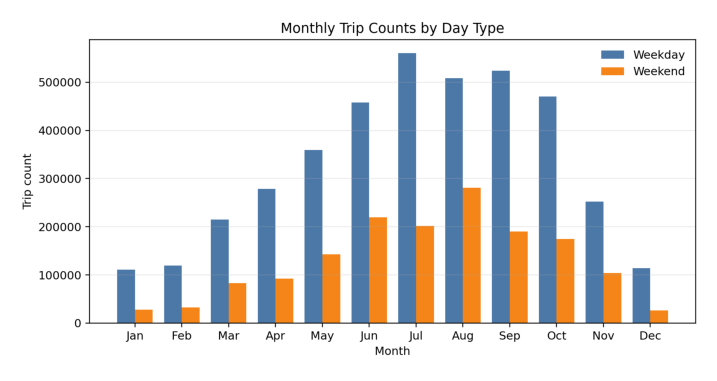

In [7]:
monthly_pivot = monthly_counts.pivot(index="month_name", columns="day_type", values="trip_count")
month_order = monthly_counts.drop_duplicates("month").sort_values("month")["month_name"]
monthly_pivot = monthly_pivot.reindex(month_order)
display(monthly_pivot)
show_png("monthly_trip_counts_by_day_type.png", figsize=(9, 5))

## Trip Duration and Trip Length

The summary statistics use the cleaned full dataset. The boxplots hide extreme visual outliers by limiting the displayed y-axis range, but the table below is based on all filtered records.

In [8]:
display(trip_summary)

,metric,day_type,count,mean,median,q1,q3,min,max
0,trip_duration_minutes,weekday,3970986,13.473,8.976,5.227,15.462,0.001,"1,439.827"
1,trip_duration_minutes,weekend,1576182,17.151,10.758,5.915,19.506,0.001,"1,439.976"
2,trip_length_km,weekday,3970986,2.178,1.598,0.909,2.831,0.000,40.565
3,trip_length_km,weekend,1576182,2.265,1.657,0.904,2.998,0.000,37.261


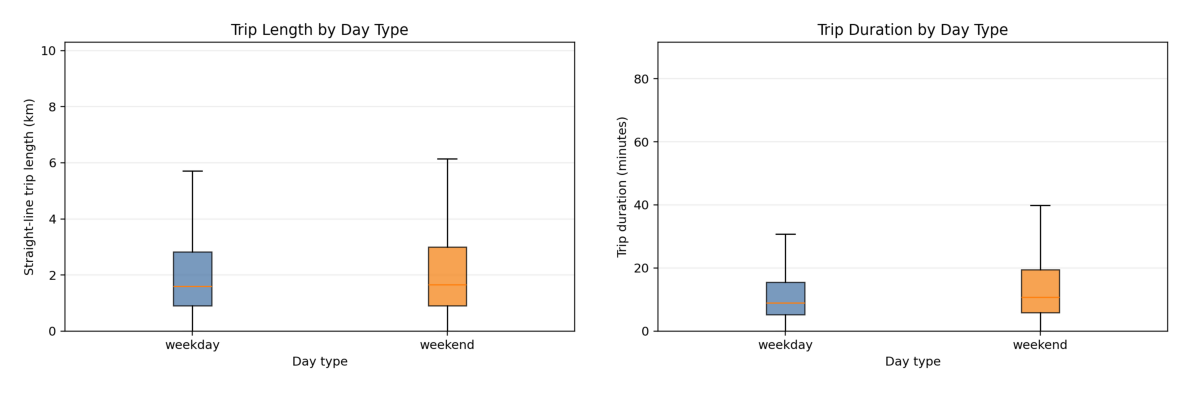

In [9]:
figure_names = ["trip_length_boxplot.png", "trip_duration_boxplot.png"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, filename in zip(axes, figure_names):
    image = mpimg.imread(FIGURES / filename)
    ax.imshow(image)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Baseline Distribution Form

The baseline movement metrics are right-skewed and long-tailed. The means are higher than the medians for trip duration, trip length, and the station-level dwell proxy, so the proposal should emphasize medians and interquartile ranges instead of relying only on averages.

Initial EDA suggests weekend trips are slightly longer and last longer than weekday trips. The median trip duration is about 10.76 minutes on weekends versus 8.98 minutes on weekdays. The median straight-line trip length is about 1.66 km on weekends versus 1.60 km on weekdays. The dwell proxy is especially long-tailed: both strata have medians near 15 minutes, while means are above 66 minutes because some stations have much longer idle gaps.


## Spatial Start-location Density

The side-by-side heatmap is the strongest proposal figure because it directly shows whether weekday and weekend trips concentrate in different parts of the city. The figure uses longitude and latitude bins rather than a basemap, which keeps the visualization reproducible and dependency-light.

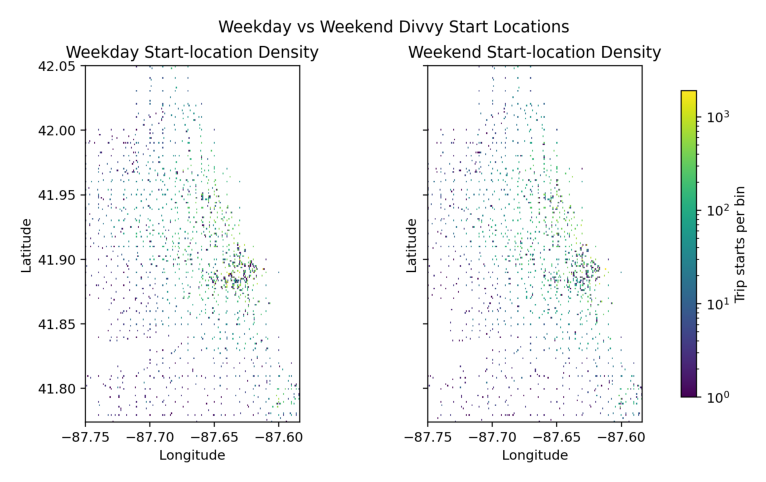

In [10]:
show_png("heatmap_start_locations_weekday_weekend.png", figsize=(11, 6))

## Normalized Weekday-Weekend Difference Heatmap

The side-by-side heatmap shows where trip starts are dense, but raw counts can be misleading because weekday trips are more numerous than weekend trips. The difference heatmap below normalizes each day type separately, then plots:

`normalized weekend start density - normalized weekday start density`

Positive cells are more weekend-leaning after normalization. Negative cells are more weekday-leaning. This is a stronger final-project comparison figure than raw side-by-side counts because it asks where the spatial pattern changes, not just where total trip volume is high.


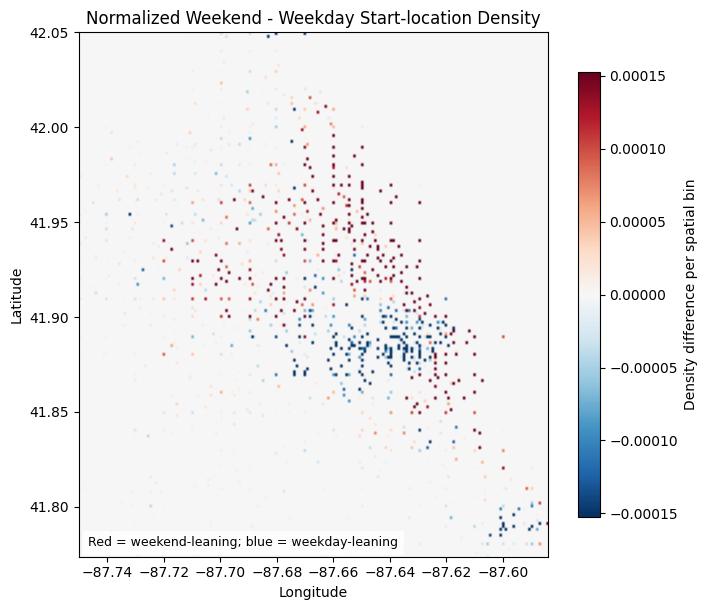

Saved normalized difference heatmap to C:\Users\peter\OneDrive\Desktop\CSC588B_Project_Code\figures\weekday_weekend_difference_heatmap.png


In [11]:
def load_start_locations_for_difference(cleaned_path: Path) -> pd.DataFrame:
    if not cleaned_path.exists():
        raise FileNotFoundError(
            f"Missing cleaned data file: {cleaned_path}. Run src/01_combine_and_clean.py first."
        )
    columns = ["day_type", "start_lat", "start_lng"]
    df = pd.read_csv(cleaned_path, usecols=columns)
    return df.dropna(subset=columns)


def plot_normalized_difference_heatmap(df: pd.DataFrame, output_path: Path, bins: int = 180) -> None:
    plot_df = df.loc[df["day_type"].isin(["weekday", "weekend"])].copy()
    lng_min, lng_max = plot_df["start_lng"].quantile([0.005, 0.995])
    lat_min, lat_max = plot_df["start_lat"].quantile([0.005, 0.995])
    plot_range = [[lng_min, lng_max], [lat_min, lat_max]]

    weekday = plot_df.loc[plot_df["day_type"] == "weekday"]
    weekend = plot_df.loc[plot_df["day_type"] == "weekend"]

    weekday_counts, x_edges, y_edges = np.histogram2d(
        weekday["start_lng"], weekday["start_lat"], bins=bins, range=plot_range
    )
    weekend_counts, _, _ = np.histogram2d(
        weekend["start_lng"], weekend["start_lat"], bins=[x_edges, y_edges]
    )

    weekday_density = weekday_counts / weekday_counts.sum()
    weekend_density = weekend_counts / weekend_counts.sum()
    difference = weekend_density - weekday_density

    limit = np.nanpercentile(np.abs(difference), 99)
    if limit == 0:
        limit = np.nanmax(np.abs(difference))

    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    image = ax.imshow(
        difference.T,
        origin="lower",
        extent=[lng_min, lng_max, lat_min, lat_max],
        cmap="RdBu_r",
        vmin=-limit,
        vmax=limit,
        aspect="auto",
    )
    ax.set_title("Normalized Weekend - Weekday Start-location Density")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    colorbar = fig.colorbar(image, ax=ax, shrink=0.85)
    colorbar.set_label("Density difference per spatial bin")
    ax.text(
        0.02,
        0.02,
        "Red = weekend-leaning; blue = weekday-leaning",
        transform=ax.transAxes,
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
    )
    fig.tight_layout()
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()


difference_heatmap_path = FIGURES / "weekday_weekend_difference_heatmap.png"
start_locations_for_difference = load_start_locations_for_difference(ROOT / "data" / "processed" / "divvy_2025_cleaned.csv")
plot_normalized_difference_heatmap(start_locations_for_difference, difference_heatmap_path)
print(f"Saved normalized difference heatmap to {difference_heatmap_path}")


## Optional Interactive Folium HeatMap

The static PNG figures above are better for the two-page PDF because they are compact and reproducible. The Folium map below is mainly for exploration and the pitch. It samples start locations with a fixed random seed, builds separate weekday and weekend heatmap layers, and saves an interactive HTML copy to `figures/interactive_start_location_heatmap.html`.


In [12]:
import matplotlib as mpl
import numpy as np
import folium
from folium.plugins import HeatMap


def from_cmap(
    cmap: str,
    alpha: float = 1.0,
    reverse: bool = False,
    num: int = 100,
) -> dict[float, str]:
    cmap_obj = mpl.colormaps[cmap]
    pctiles = np.linspace(0, 1, num=num + 1)[1:]

    def rgba_to_string(r: float, g: float, b: float, a: float) -> str:
        return f"rgba({int(r * 255)}, {int(g * 255)}, {int(b * 255)}, {a:.3f})"

    gradient = {}
    for pct in pctiles:
        value = 1 - pct if reverse else pct
        gradient[float(pct)] = rgba_to_string(*cmap_obj(value, alpha=alpha))
    return gradient


def sample_start_locations(cleaned_path: Path, max_points_per_day_type: int = 2500) -> pd.DataFrame:
    if not cleaned_path.exists():
        raise FileNotFoundError(
            f"Missing cleaned data file: {cleaned_path}. Run src/01_combine_and_clean.py first."
        )

    columns = ["day_type", "start_lat", "start_lng"]
    chunk_samples = []
    per_chunk_target = max(100, max_points_per_day_type // 12)

    for chunk_number, chunk in enumerate(pd.read_csv(cleaned_path, usecols=columns, chunksize=250_000)):
        chunk = chunk.dropna(subset=columns)
        for day_type in ["weekday", "weekend"]:
            group = chunk.loc[chunk["day_type"] == day_type]
            if group.empty:
                continue
            take = min(len(group), per_chunk_target)
            chunk_samples.append(group.sample(n=take, random_state=42 + chunk_number))

    if not chunk_samples:
        raise ValueError("No start-location records were available for the interactive heatmap.")

    sampled = pd.concat(chunk_samples, ignore_index=True)
    balanced_samples = []
    for day_type in ["weekday", "weekend"]:
        group = sampled.loc[sampled["day_type"] == day_type]
        take = min(len(group), max_points_per_day_type)
        balanced_samples.append(group.sample(n=take, random_state=42))

    return pd.concat(balanced_samples, ignore_index=True)


cleaned_data_path = ROOT / "data" / "processed" / "divvy_2025_cleaned.csv"
interactive_heatmap_path = FIGURES / "interactive_start_location_heatmap.html"
heatmap_points = sample_start_locations(cleaned_data_path)

m = folium.Map(
    location=[heatmap_points["start_lat"].mean(), heatmap_points["start_lng"].mean()],
    zoom_start=11,
    tiles="CartoDB positron",
)

for day_type, label, cmap_name, show_layer in [
    ("weekday", "Weekday start locations", "viridis", True),
    ("weekend", "Weekend start locations", "magma", False),
]:
    layer_points = heatmap_points.loc[heatmap_points["day_type"] == day_type, ["start_lat", "start_lng"]]
    layer = folium.FeatureGroup(name=label, show=show_layer)
    HeatMap(
        data=layer_points.values.tolist(),
        radius=9,
        blur=13,
        min_opacity=0.25,
        max_zoom=13,
        gradient=from_cmap(cmap_name, alpha=0.85, num=16),
    ).add_to(layer)
    layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m.save(interactive_heatmap_path)
print(f"Saved interactive heatmap to {interactive_heatmap_path}")
m


Saved interactive heatmap to C:\Users\peter\OneDrive\Desktop\CSC588B_Project_Code\figures\interactive_start_location_heatmap.html


## Station-level Dwell Time Proxy

The dwell proxy is calculated as the time from an arrival event at a station to the next departure event at the same station. This is a **station-level availability or idle-time proxy**, not true bike-level dwell time, because the public Divvy data does not include `bike_id`.

For the proposal, this metric should stay simple. The chart below only compares the median dwell proxy for weekdays and weekends. The main takeaway is that the two medians are very close, so dwell proxy is supporting evidence rather than a main source of weekday/weekend difference.


,day_type,count,median,mean
0,weekday,3074864,15.770,66.210
1,weekend,1197013,15.090,67.110


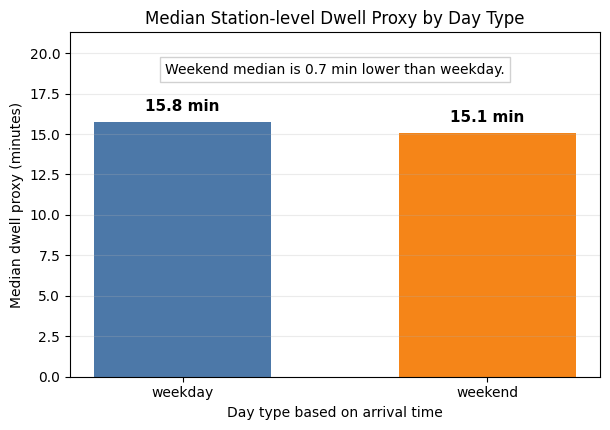

Saved dwell proxy median bar chart to C:\Users\peter\OneDrive\Desktop\CSC588B_Project_Code\figures\dwell_proxy_median_bar.png


In [13]:
dwell_summary_for_display = dwell_summary.copy()
for column in ["mean", "median", "q1", "q3"]:
    dwell_summary_for_display[column] = dwell_summary_for_display[column].round(2)

display(dwell_summary_for_display[["day_type", "count", "median", "mean"]])


def plot_dwell_median_bar(summary: pd.DataFrame, output_path: Path) -> None:
    plot_df = summary.set_index("day_type").loc[["weekday", "weekend"]].reset_index()
    colors = ["#4C78A8", "#F58518"]

    fig, ax = plt.subplots(figsize=(6.2, 4.4))
    bars = ax.bar(plot_df["day_type"], plot_df["median"], color=colors, width=0.58)

    for bar, median in zip(bars, plot_df["median"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.45,
            f"{median:.1f} min",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

    weekday_median = float(plot_df.loc[plot_df["day_type"] == "weekday", "median"].iloc[0])
    weekend_median = float(plot_df.loc[plot_df["day_type"] == "weekend", "median"].iloc[0])
    difference = weekend_median - weekday_median

    ax.set_title("Median Station-level Dwell Proxy by Day Type")
    ax.set_xlabel("Day type based on arrival time")
    ax.set_ylabel("Median dwell proxy (minutes)")
    ax.set_ylim(0, max(plot_df["median"]) * 1.35)
    ax.grid(axis="y", alpha=0.25)
    ax.text(
        0.5,
        0.88,
        f"Weekend median is {abs(difference):.1f} min {'lower' if difference < 0 else 'higher'} than weekday.",
        transform=ax.transAxes,
        ha="center",
        fontsize=10,
        bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "#cccccc"},
    )
    fig.tight_layout()
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()


dwell_bar_path = FIGURES / "dwell_proxy_median_bar.png"
plot_dwell_median_bar(dwell_summary, dwell_bar_path)
print(f"Saved dwell proxy median bar chart to {dwell_bar_path}")


## Recommended Proposal Figures

For the two-page proposal, use only one or two high-value figures in the main text:

1. `weekday_weekend_difference_heatmap.png` or `heatmap_start_locations_weekday_weekend.png` - best figure for the spatial comparison.
2. `trip_length_boxplot.png` / `trip_duration_boxplot.png` - useful support for the movement-distribution comparison.

`monthly_trip_counts_by_day_type.png` is useful evidence that the dataset covers the full year, but it can be mentioned in text or moved to an appendix if space is tight. Keep the proposal focused on the figures that directly answer the research question.


## Final Project Deliverables

The final project will produce:

1. A reproducible cleaned 2025 Divvy trip dataset generated from the raw monthly files.
2. Summary tables for weekday/weekend trip duration, straight-line distance, rider type, bike type, and season.
3. Static figures for monthly coverage, distribution comparison, side-by-side spatial density, and normalized weekday-weekend spatial difference.
4. A ranked list of weekday-leaning and weekend-leaning stations or spatial bins.
5. An optional interactive Folium heatmap for the class pitch.


## Analysis Plan and Paper Connection

The final analysis will follow a five-step pipeline:

1. Clean and validate the full-year Divvy dataset, keeping a reproducible record of filtering decisions and final row counts.
2. Compare weekday and weekend trip duration and straight-line trip length using median/IQR summaries, boxplots, and final-project ECDF plots.
3. Analyze start-location density with both side-by-side heatmaps and a normalized weekday-weekend difference heatmap.
4. Identify the stations or spatial bins with the largest weekday-leaning and weekend-leaning differences, then interpret whether they align with commute corridors, downtown areas, parks, lakefront areas, or leisure districts.
5. Optionally merge NOAA daily weather fields and test whether precipitation, snow, and temperature help explain daily trip volume after day type and season are considered.

This connects directly to Zhou (2015), who analyzed Chicago Divvy spatiotemporal biking behavior by separating weekday/weekend patterns, user groups, flows, and station demand. It also connects to Chiariotti et al. (2018), where historical bike-share demand is used to understand station availability and rebalancing needs. This project is narrower than those papers: it focuses first on a reproducible weekday/weekend comparison for 2025 Chicago, then uses hotspot ranking and optional weather fields as final-project extensions.

Key limitations:

- Straight-line distance is not the actual route distance.
- Public Divvy data does not include `bike_id`, so dwell time can only be measured as a station-level proxy.
- The station-level dwell proxy measures time between an arrival at a station and the next departure from that station; it does not prove that the same physical bike stayed there.
- The heatmaps show density of observed trip starts, not unmet demand from empty or full stations.

References to use in the written proposal:

- Zhou, X. (2015). Understanding Spatiotemporal Patterns of Biking Behavior by Analyzing Massive Bike Sharing Data in Chicago. PLOS ONE, 10(10), e0137922. https://doi.org/10.1371/journal.pone.0137922
- Chiariotti, F., Pielli, C., Zanella, A., & Zorzi, M. (2018). A Dynamic Approach to Rebalancing Bike-Sharing Systems. Sensors, 18(2), 512. https://doi.org/10.3390/s18020512
